In [1]:
# CELL 1: Imports
import os
import random
import shutil
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
# CELL 2: Configurations
import configs

print("Using device:", configs.DEVICE)

Using device: cuda


In [3]:
# CELL 3: Inspect raw dataset

data_path = Path(configs.DATA_DIR)

CLASS_NAMES = sorted(
    [folder.name for folder in data_path.iterdir() if folder.is_dir()]
)

NUM_CLASSES = len(CLASS_NAMES)

print("Classes found:", CLASS_NAMES)
print("Number of classes found:", NUM_CLASSES)

total_images = 0

for class_name in CLASS_NAMES:
    class_path = data_path / class_name
    image_count = len(list(class_path.glob("*")))
    total_images += image_count
    print(f"{class_name}: {image_count} images")

print(f"\nTotal images: {total_images}")

Classes found: ['kia_carnival', 'kia_ev6', 'kia_seltos', 'kia_sonet']
Number of classes found: 4
kia_carnival: 901 images
kia_ev6: 874 images
kia_seltos: 1070 images
kia_sonet: 815 images

Total images: 3660


# Splitting the Data into Train, Test, Validation 
```
data_split/
    train/
        bike/
        car/
    val/
        bike/
        car/
    test/
        bike/
        car/
```

In [4]:
# CELL 4: Split dataset safely

from PIL import Image

source_path = Path(configs.DATA_DIR)
split_path = Path(configs.SPLIT_DIR)

if split_path.exists():
    shutil.rmtree(split_path)

def is_valid_image(filepath):
    try:
        with Image.open(filepath) as img:
            img.verify()
        return True
    except:
        return False

for cls in CLASS_NAMES:
    all_files = list((source_path / cls).glob("*"))

    valid_files = []

    for file in all_files:
        if is_valid_image(file):
            valid_files.append(file)
        else:
            print(f"Skipping corrupted file: {file}")

    random.shuffle(valid_files)

    total = len(valid_files)

    train_end = int(total * configs.TRAIN_SPLIT)
    val_end = train_end + int(total * configs.VAL_SPLIT)

    train_files = valid_files[:train_end]
    val_files = valid_files[train_end:val_end]
    test_files = valid_files[val_end:]

    for split_name, file_list in {
        "train": train_files,
        "val": val_files,
        "test": test_files
    }.items():

        target_dir = split_path / split_name / cls
        target_dir.mkdir(parents=True, exist_ok=True)

        for file in file_list:
            shutil.copy(file, target_dir / file.name)

print("Dataset split complete.")

Skipping corrupted file: data\kia_carnival\2.5 lakh me kia carnival limousine.jpg
Skipping corrupted file: data\kia_carnival\2020 KIA CARNIVAL LIMOUSINE 7STR Just.jpg
Skipping corrupted file: data\kia_carnival\2021 Kia Carnival Auto 59,357 kms.jpg
Skipping corrupted file: data\kia_carnival\2021 KIA CARNIVAL FOR SALE ✨ Automatic.jpg
Skipping corrupted file: data\kia_carnival\2022 Kia carnival Limousine (sold) 7.jpg
Skipping corrupted file: data\kia_carnival\2022, Kia Carnival , Diesel AT, Kms-001.jpg
Skipping corrupted file: data\kia_carnival\2022, Kia Carnival , Diesel AT, Kms.jpg
Skipping corrupted file: data\kia_carnival\2023 Variant of Kia Carnival gets.jpg
Skipping corrupted file: data\kia_carnival\2nd hand KIA GRAND CARNIVAL YP.jpg
Skipping corrupted file: data\kia_carnival\buying a second-hand Kia Carnival.jpg
Skipping corrupted file: data\kia_carnival\Call 8708383031 Kia Carnival 2021 in.jpg
Skipping corrupted file: data\kia_carnival\car Kia Carnival-001.jpg
Skipping corrupted f

In [5]:
# CELL 5: Image Transforms
from inference import transform_image, transform_train_image

train_transform = lambda image: transform_train_image(image, configs.IMAGE_SIZE)

test_transform = lambda image: transform_image(image, configs.IMAGE_SIZE)

In [6]:
# CELL 6: Create the datasets
# Create datasets

train_dataset = datasets.ImageFolder(
    root=Path(configs.SPLIT_DIR) / "train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=Path(configs.SPLIT_DIR) / "val",
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    root=Path(configs.SPLIT_DIR) / "test",
    transform=test_transform
)

print("Class indices:", train_dataset.class_to_idx)
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Class indices: {'kia_carnival': 0, 'kia_ev6': 1, 'kia_seltos': 2, 'kia_sonet': 3}
Train samples: 2893
Validation samples: 360
Test samples: 364


In [7]:
# CELL 7: Data Loaders
# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=configs.BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=configs.BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=configs.BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 46
Validation batches: 6
Test batches: 6


c:\Users\rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


torch.Size([64, 3, 512, 512])


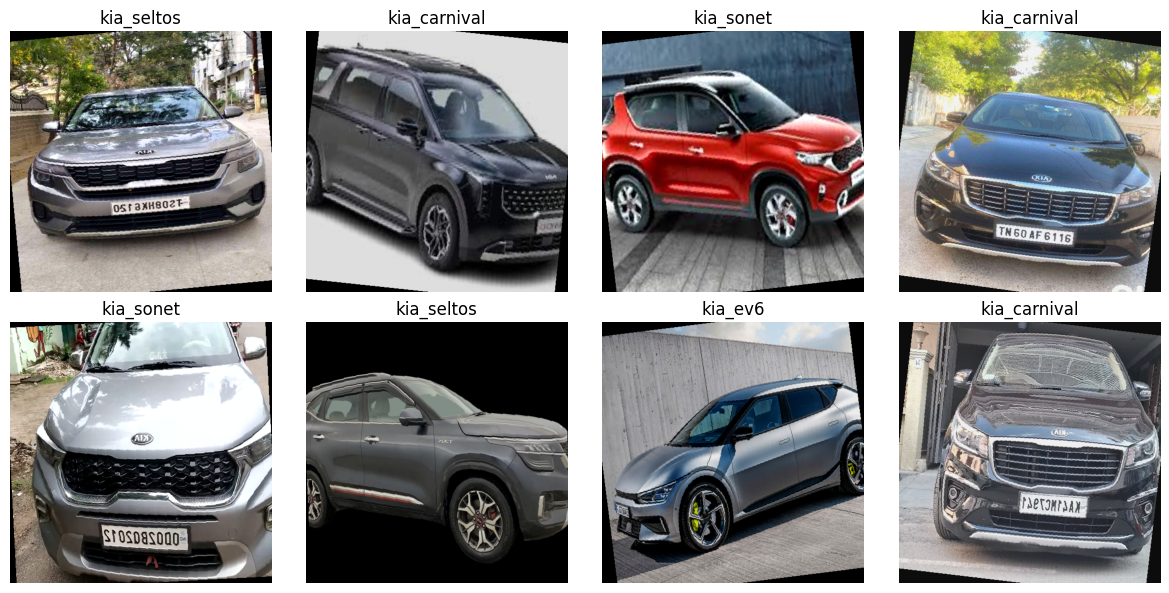

In [8]:
# CELL 8: Visual Checks

images, labels = next(iter(train_loader))
print(images.shape)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    img = images[i]

    # Convert from [C,H,W] to [H,W,C]
    img = img.permute(1, 2, 0).numpy()

    # Undo normalization for display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = (img * std) + mean
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# CELL 9: Load pretrained resnet50

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Replace final classifier
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Move model to GPU/CPU
model = model.to(configs.DEVICE)

print(model.fc)
print("Model loaded on:", configs.DEVICE)

Linear(in_features=2048, out_features=4, bias=True)
Model loaded on: cuda


In [10]:
# Freeze entire backbone first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model.fc.parameters():
    param.requires_grad = True

print("Layer4 and classifier head trainable.")

Layer4 and classifier head trainable.


In [11]:
# CELL 11: Loss function and optimizer

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

print("Loss and optimizer configured.")

Loss and optimizer configured.


In [12]:
# CELL 12: Training funtion
from train import train_one_epoch, validate

In [13]:
# CELL 13: Main training loop

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

num_epochs = configs.EPOCHS # Change here if you want to fine tune for more epochs after initial training

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model = model,
        dataloader = train_loader,
        loss_fn = loss_fn,
        optimizer = optimizer,
        device = configs.DEVICE
    )

    val_loss, val_acc = validate(
        model = model,
        dataloader = val_loader,
        loss_fn = loss_fn,
        device = configs.DEVICE
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.2f}%")
    print("-" * 50)

Epoch [1/40]
Train Loss: 1.3709 | Train Accuracy: 32.42%
Val Loss:   1.3531 | Val Accuracy:   37.22%
--------------------------------------------------
Epoch [2/40]
Train Loss: 1.3253 | Train Accuracy: 41.17%
Val Loss:   1.3054 | Val Accuracy:   43.61%
--------------------------------------------------
Epoch [3/40]
Train Loss: 1.2473 | Train Accuracy: 49.95%
Val Loss:   1.2096 | Val Accuracy:   50.00%
--------------------------------------------------
Epoch [4/40]
Train Loss: 1.1125 | Train Accuracy: 60.70%
Val Loss:   1.0293 | Val Accuracy:   63.06%
--------------------------------------------------
Epoch [5/40]
Train Loss: 0.9087 | Train Accuracy: 73.38%
Val Loss:   0.7662 | Val Accuracy:   81.94%
--------------------------------------------------
Epoch [6/40]
Train Loss: 0.6978 | Train Accuracy: 83.17%
Val Loss:   0.5556 | Val Accuracy:   86.94%
--------------------------------------------------
Epoch [7/40]
Train Loss: 0.5300 | Train Accuracy: 87.94%
Val Loss:   0.4393 | Val Accura

KeyboardInterrupt: 

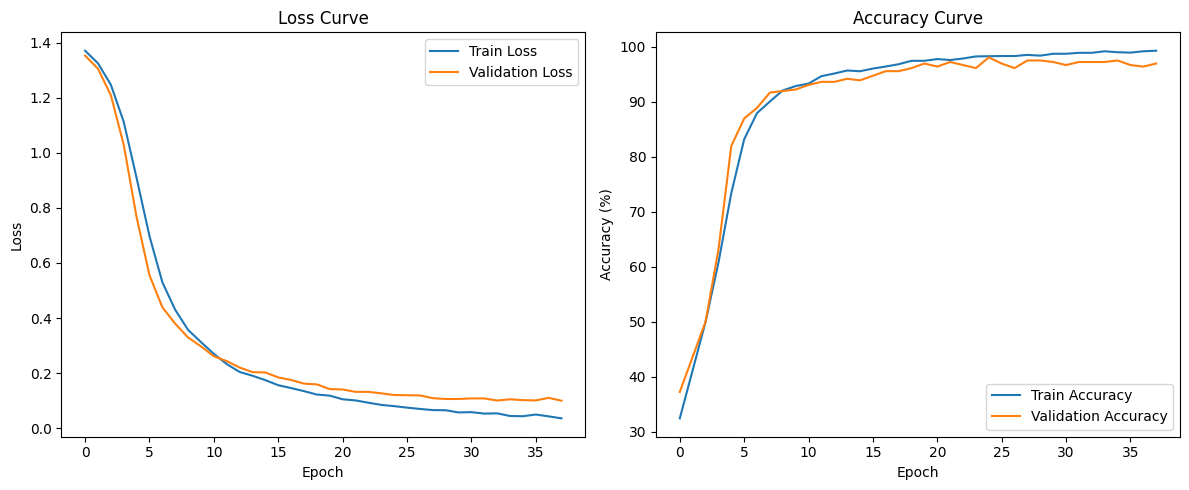

In [14]:
# CELL 15: Plot training curves

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

Test Accuracy: 96.43%

Classification Report:
              precision    recall  f1-score   support

kia_carnival       0.99      0.98      0.98        87
     kia_ev6       0.99      0.95      0.97        88
  kia_seltos       0.92      0.99      0.95       107
   kia_sonet       0.97      0.93      0.95        82

    accuracy                           0.96       364
   macro avg       0.97      0.96      0.96       364
weighted avg       0.97      0.96      0.96       364



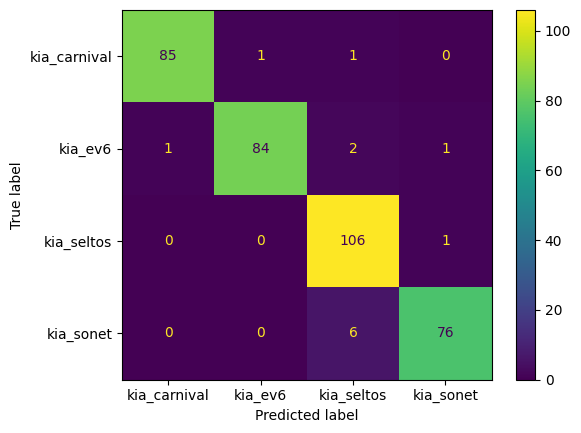

In [15]:
# CELL 16: Test evaluation

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(configs.DEVICE)
        labels = labels.to(configs.DEVICE)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * np.mean(np.array(all_predictions) == np.array(all_labels))

print(f"Test Accuracy: {test_accuracy:.2f}%")

print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot()
plt.show()

In [ ]:
# CELL 17: Save model

os.makedirs("models", exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": CLASS_NAMES,
    "num_classes": NUM_CLASSES,
    "image_size": configs.IMAGE_SIZE,
    "architecture": "ResNet50"
}, "models/final_model_v3.pth")

print("Model saved successfully.")

Model saved successfully.
